In [1]:
#import requests
#requests.get('http://www.google.com',timeout=10).ok

try:
    from easypip import easyimport
except ModuleNotFoundError:
    from subprocess import run
    assert run(["pip", "install", "easypip"]).returncode == 0, "Could not install easypip"
    from easypip import easyimport

easyimport("swig")
easyimport("bbrl_utils").setup()

import copy
import os

import torch
import torch.nn as nn
from bbrl.agents import Agent, Agents, KWAgentWrapper, TemporalAgent
from bbrl_utils.algorithms import EpisodicAlgo, iter_partial_episodes
from bbrl_utils.nn import build_ortho_mlp, setup_optimizer
from bbrl_utils.notebook import setup_tensorboard
from bbrl.workspace import Workspace
from omegaconf import OmegaConf
from bbrl.utils.functional import gae
from bbrl_utils.nn import copy_parameters

/opt/homebrew/anaconda3/envs/mon_env/lib/python3.10/site-packages/bbrl_utils/notebook.py:46: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm  # noqa: F401


In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

In [29]:
import kaggle_environments
import Chessnut

In [3]:
from kaggle_environments import make
env = make("chess", debug=True)
print(env)

termcolor not installed, skipping dependency


In [4]:
%%writefile main.py
from Chessnut import Game
import random
import chess

def reward(move, obs):
    g = Game(obs.board)
    g.apply_move(move)
    if g.status == Game.CHECKMATE:
        return 20
    game = Game(obs.board)
    if game.board.get_piece(Game.xy2i(move[2:4])) == 'q':
        return 9
    elif game.board.get_piece(Game.xy2i(move[2:4])) == 'r':
        return 5
    elif game.board.get_piece(Game.xy2i(move[2:4])) == 'n':
        return 3
    elif game.board.get_piece(Game.xy2i(move[2:4])) == 'b':
        return 3
    elif game.board.get_piece(Game.xy2i(move[2:4])) == 'p':
        return 1
    elif game.board.get_piece(Game.xy2i(move[2:4])) == 'Q':
        return -9
    elif game.board.get_piece(Game.xy2i(move[2:4])) == 'R':
        return -5
    elif game.board.get_piece(Game.xy2i(move[2:4])) == 'N':
        return -3
    elif game.board.get_piece(Game.xy2i(move[2:4])) == 'B':
        return -3
    elif game.board.get_piece(Game.xy2i(move[2:4])) == 'P':
        return -1
    elif "q" in move.lower():
        return 9
    else:
        return 0

def chess_bot(obs):
    print(obs.board)
    game = Game(obs.board)
    moves = list(game.get_moves())
    best_move = random.choice(moves)
    best_reward = 0
    for move in moves:
        r = reward(move, obs)
        if r > best_reward:
            best_reward = r
            best_move = move
    return best_move

Overwriting main.py


rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1
rnbqkbnr/ppp1pppp/8/3p4/P7/8/1PPPPPPP/RNBQKBNR w KQkq d6 0 2
rn1qkbnr/ppp1pppp/8/3p4/P7/7b/RPPPPPPP/1NBQKBNR w Kkq - 2 3
rn1qkbnr/ppp1pppp/8/8/P2p4/7P/RPPPPP1P/1NBQKBNR w Kkq - 0 4
rn1qkbnr/ppp1ppp1/7p/8/P2p1P2/7P/RPPPP2P/1NBQKBNR w Kkq - 0 5
rn1qkbnr/ppp1p1p1/5p1p/8/P2p1P2/2N4P/RPPPP2P/2BQKBNR w Kkq - 0 6
rn2kbnr/pppqp1p1/5p1p/8/P2p1P2/2N4P/1PPPP2P/R1BQKBNR w Kkq - 2 7
rn2kbnr/pppqp1p1/5p2/3N3p/P2p1P2/7P/1PPPP2P/R1BQKBNR w Kkq - 0 8
rn2kbnr/pppqp3/5p2/7p/P2p1P2/7P/1PPPP2P/R1BQKBNR w Kkq - 0 9
rn2kbnr/ppp1p3/5p2/1q5p/P2p1P2/R6P/1PPPP2P/2BQKBNR w Kkq - 2 10
rn2kbnr/pp2p3/5p2/1Pp4p/3p1P2/R6P/1PPPP2P/2BQKBNR w Kkq c6 0 11
rn2kbnr/Rp2p3/5p2/1P5p/2pp1P2/7P/1PPPP2P/2BQKBNR w Kkq - 0 12
Rn2kb1r/1p2p3/5p1n/1P5p/2pp1P2/7P/1PPPP2P/2BQKBNR w Kk - 1 13
1R3b1r/1p1kp3/5p1n/1P5p/2pp1P2/7P/1PPPP2P/2BQKBNR w K - 1 14
5R1r/1p1kp3/5p1n/1P5p/3p1P2/2p4P/1PPPP2P/2BQKBNR w K - 0 15
7R/1p2p3/4kp1n/1P5p/3p1P2/2p4P/1PPPP2P/2BQKBNR w K - 1 16
8/1p2p3/4kp1R


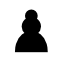
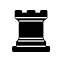
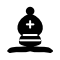
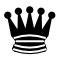
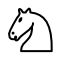
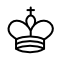
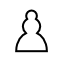
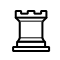
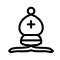
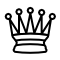
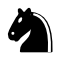
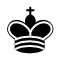

In [5]:
result = env.run(["main.py", "random"])
print("Agent exit status/reward/time left: ")
# look at the generated replay.json and print out the agent info
for agent in result[-1]:
    print("\t", agent.status, "/", agent.reward, "/", agent.observation.remainingOverageTime)
print("\n")
# render the game
env.render(mode="ipython", width=1000, height=1000) 

In [1]:
from Chessnut import Game
class ChessEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.game = Game()  
        self.observation_space = spaces.Box(low=np.zeros(66), high= np.ones(66)*50, dtype=int)
        self.action_space = spaces.Box(low = np.zeros(60), high = np.ones(60)) 

    
    def reset(self, **kwargs):
        self.game = Game()
        info = {'number': self.game.status}
        return self.get_observation(), info

    def step(self, action):
        liste_moves = self.game.get_moves()
        value = int(action) % len(liste_moves)
        move = liste_moves[value - 1]
        reward = self.compute_reward(move)
        print(reward, 'reward')
        self.game.apply_move(move)
        unsufficient_materiel = self.unsufficient_materiel()
        length_game = len(self.game.move_history)
        print(length_game, "length_game")
        done = (self.game.status == 2) or (self.game.status == 3) or unsufficient_materiel or (length_game > 100)
        info = {'number': self.game.status}
        print(self.game.board.__str__())
        return self.get_observation(), reward, False, done, info

    def unsufficient_materiel(self):
        if self.game.board.find_piece('p') != -1 or self.game.board.find_piece('P') != -1 or self.game.board.find_piece('q') != -1 or self.game.board.find_piece('Q') != -1 or self.game.board.find_piece('r') != -1 or self.game.board.find_piece('R') != -1:
            return False
        if (self.game.board.find_piece('n') != -1 and self.game.board.find_piece('b') != -1) or (self.game.board.find_piece('N') != -1 and self.game.board.find_piece('B') != -1):
            return False
        return True

    def get_observation(self):
        fen = self.game.board._position
        obs = np.zeros((66), dtype=int)
        for i in range(len(fen)):
            if fen[i] == ' ':
                obs[i] = 0
            elif fen[i] == 'r':
                obs[i] = 1
            elif fen[i] == 'n':
                obs[i] = 2
            elif fen[i] == 'b':
                obs[i] = 3
            elif fen[i] == 'q':
                obs[i] = 4
            elif fen[i] == 'k':
                obs[i] = 5
            elif fen[i] == 'p':
                obs[i] = 6 
            elif fen[i] == 'R':
                obs[i] = 7
            elif fen[i] == 'N':
                obs[i] = 8
            elif fen[i] == 'B':
                obs[i] = 9
            elif fen[i] == 'Q':
                obs[i] = 10
            elif fen[i] == 'K':
                obs[i] = 11
            elif fen[i] == 'P':
                obs[i] = 12 
        obs[64] = len(self.game.get_moves())
        if self.game.get_fen().split()[1] == 'w':
            obs[-1] = 1
        else:
            obs[-1] = 0
        obs = obs.astype(float)
        return obs
    
    def compute_reward(self, action):
        reward = 0
        move = action
        fen = self.game.get_fen()
        g = Game(fen)
        g.apply_move(move)
        if g.status == Game.CHECKMATE:
            return 30
        if g.status == Game.STALEMATE:
            return 0
        list_prochain_moves = list(g.get_moves())
        next_move = random.choice(list_prochain_moves)
        if self.game.board.get_piece(Game.xy2i(move[2:4])) == 'Q':
            reward += 9
        elif self.game.board.get_piece(Game.xy2i(move[2:4])) == 'R':
            reward += 5
        elif self.game.board.get_piece(Game.xy2i(move[2:4])) == 'N':
            reward += 3
        elif self.game.board.get_piece(Game.xy2i(move[2:4])) == 'B':
            reward += 3
        elif self.game.board.get_piece(Game.xy2i(move[2:4])) == 'P':
            reward += 1
        elif "q" in move.lower():
            reward += 9
        elif g.board.get_piece(Game.xy2i(next_move[2:4])) == 'q':
            reward -= 9
        elif g.board.get_piece(Game.xy2i(next_move[2:4])) == 'r':
            reward -= 5
        elif g.board.get_piece(Game.xy2i(next_move[2:4])) == 'n':
            reward -= 3
        elif g.board.get_piece(Game.xy2i(next_move[2:4])) == 'b':
            reward -= 3
        elif g.board.get_piece(Game.xy2i(next_move[2:4])) == 'p':
            reward -= 1
        return reward

NameError: name 'gym' is not defined

In [47]:
from gymnasium.envs.registration import register

register(
    id="ChessEnv-v0",
    entry_point="__main__:ChessEnv",  # Chemin vers votre classe
)

In [48]:
params = {
    "base_dir": "${gym_env.env_name}/ppo-kl-S${algorithm.seed}-b${algorithm.beta}_${current_time:}",
    "save_best": False,
    "algorithm": {
        "seed": 12,
        "n_envs": 2,
        "n_steps": 3,
        "normalize_advantage": False,
        "eval_interval": 1000,
        "nb_evals": 10,
        "gae": 0.8,
        "discount_factor": 0.98,
        "opt_epochs": 10,
        "batch_size": 256,
        "max_grad_norm": 0.5,
        "policy_coef": 1.,
        "beta": 5.0,
        "clip_range_vf": 0,
        "entropy_coef": 2e-7,
        "critic_coef": 1.0,
        "policy_type": "DiscretePolicy",
        "architecture": {
            "actor_hidden_size": [64, 64],
            "critic_hidden_size": [64, 64],
        },
        "max_epochs": 5000,
    },
    "gym_env": {
        "env_name": "ChessEnv-v0",
    },
    "optimizer": {
        "classname": "torch.optim.Adam",
        "lr": 1e-3,
        "eps": 1e-5,
    },
}

In [37]:
class AdaptiveMLP(nn.Module):
    def __init__(self, list_dim , activation=nn.ReLU):
        super().__init__()
        self.hidden = nn.Linear(list_dim[0], list_dim[1])
        self.output = nn.Linear(list_dim[-2], list_dim[-1])
        self.activation = activation
        self.len = len(list_dim)
        self.list_dim = list_dim


    def forward(self, x, i_values):
        x = self.activation(self.hidden(x))
        for i in range(self.len - 3):
            F = nn.Linear(self.list_dim[i+1], self.list_dim[i+2])
            x = self.activation(F(x))
        outputs = self.output(x)
        for j in range(len(outputs)):
            if j > i_values[0]:
                outputs[j] = -10
        return outputs
   

class KLAgent(Agent):
    def __init__(self, model_1, model_2):
        super().__init__()
        self.model_1 = model_1
        self.model_2 = model_2

    def forward(self, t, **kwargs):
        obs = self.get(("env/env_obs", t))
        dist_1 = self.model_1.dist(obs)
        dist_2 = self.model_2.dist(obs)
        kl = torch.distributions.kl.kl_divergence(dist_1, dist_2)
        self.set(("kl", t), kl)

class VAgent(Agent):
    def __init__(self, state_dim, hidden_layers, name="critic"):
        super().__init__(name=name)
        self.is_q_function = False
        self.model = build_ortho_mlp(
            [state_dim] + list(hidden_layers) + [1], activation=nn.ReLU()
        )

    def forward(self, t, **kwargs):
        observation = self.get(("env/env_obs", t))
        critic = self.model(observation).squeeze(-1)
        self.set((f"{self.prefix}v_values", t), critic)

In [38]:
class DiscretePolicy(Agent):
    def __init__(self, state_dim, hidden_size, n_actions, name="policy"):
        super().__init__(name=name)
        self.model = AdaptiveMLP(
            [state_dim] + list(hidden_size) + [n_actions], activation=nn.ReLU()
        )

    def dist(self, obs):
        observation = obs[:,:64]
        i_values = obs[:,64]
        print(observation)
        scores = self.model(observation, i_values)
        probs = torch.softmax(scores, dim=-1)
        return torch.distributions.Categorical(probs)

    def forward(
        self,
        t,
        *,
        stochastic=True,
        predict_proba=False,
        compute_entropy=False,
        **kwargs,
    ):
        
        observation = self.get(("env/env_obs", t))
        obs = observation[:,:64]
        i_values = observation[:,64]
        white = (observation[:,-1] == 1)
        if white[0]:
            scores = self.model(obs, i_values)
            probs = torch.softmax(scores, dim=-1).squeeze(1)
            if predict_proba:
                action = self.get(("action", t))
                log_probs = probs[torch.arange(probs.size()[0]), action].log()
                print(log_probs, "log probs")
                self.set((f"{self.prefix}logprob_predict", t), log_probs)
            else:
                if stochastic:
                    action = torch.distributions.Categorical(probs).sample()
                else:
                    action = scores.argmax(1)
                self.set(("action", t), action)

            if compute_entropy:
                entropy = torch.distributions.Categorical(probs).entropy()
                self.set((f"{self.prefix}entropy", t), entropy)
        else :
            action = torch.zeros(len(i_values), dtype = torch.int64)
            for i in range(len(i_values)):
                if i_values[i] != 0:
                    action[i] = random.choice(np.arange(i_values[i]))
            if predict_proba:
                self.set((f"{self.prefix}logprob_predict", t), torch.zeros(2, dtype = torch.float32))
            else:
                self.set(("action",t), action)

    def chess_bot(self,obs):
        observation = obs[:64]
        i_values = obs[64]
        scores = self.model(observation, i_values)
        probs = torch.softmax(scores, dim=-1)
        return torch.distributions.Categorical(probs)

In [50]:
class PPOPenalty(EpisodicAlgo):
    def __init__(self, cfg):
        super().__init__(cfg, autoreset=True)
        print(self.train_env.get_observation_space())
        obs_size, act_size = self.train_env.get_obs_and_actions_sizes()
        self.train_policy = globals()[cfg.algorithm.policy_type](
            obs_size - 2,                                       #On enlève la dernière valeur qui est le nombre de moves
            cfg.algorithm.architecture.actor_hidden_size,
            act_size,
        ).with_prefix("current_policy/")
        print(self.train_policy)
        self.eval_policy = KWAgentWrapper(
            self.train_policy, 
            stochastic=False,
            predict_proba=False,
            compute_entropy=False,
        )
        self.critic_agent = VAgent(
            obs_size, cfg.algorithm.architecture.critic_hidden_size
        ).with_prefix("critic/")
        self.old_critic_agent = copy.deepcopy(self.critic_agent).with_prefix("old_critic/")
        self.t_all_critics = TemporalAgent(
            Agents(self.critic_agent, self.old_critic_agent)
        )
        self.old_policy = copy.deepcopy(self.train_policy)
        self.old_policy.with_prefix("old_policy/")
        
        self.t_kl_agent = TemporalAgent(KLAgent(self.old_policy, self.train_policy))

        self.policy_optimizer = setup_optimizer(
            cfg.optimizer, self.train_policy
        )
        self.critic_optimizer = setup_optimizer(
            cfg.optimizer, self.critic_agent
        )

In [40]:
def save_ppo_model(ppo_instance, filename):
    checkpoint = {
        'train_policy_state_dict': ppo_instance.train_policy.state_dict(),
        'critic_agent_state_dict': ppo_instance.critic_agent.state_dict(),
        'old_policy_state_dict': ppo_instance.old_policy.state_dict(),
        'old_critic_agent_state_dict': ppo_instance.old_critic_agent.state_dict(),
        'policy_optimizer_state_dict': ppo_instance.policy_optimizer.state_dict(),
        'critic_optimizer_state_dict': ppo_instance.critic_optimizer.state_dict(),
        'config': ppo_instance.cfg, 
    }

    torch.save(checkpoint, filename)
    print(f"Modèle PPO sauvegardé dans le fichier : {filename}")

In [41]:
from bbrl.utils.functional import gae


def run_ppo_penalty(ppo: PPOPenalty):
    cfg = ppo.cfg

    # The old_policy params must be wrapped into a TemporalAgent
    t_old_policy = TemporalAgent(ppo.old_policy)

    # Training loop
    for train_workspace in ppo.iter_partial_episodes():
        # Run the current policy and evaluate the proba of its action according
        # to the old policy The old_policy can be run after the train_agent on
        # the same workspace because it writes a logprob_predict and not an
        # action. That is, it does not determine the action of the old_policy,
        # it just determines the proba of the action of the current policy given
        # its own probabilities

        # Compute the critic value over the whole workspace
        ppo.t_all_critics(train_workspace, t=0, n_steps=cfg.algorithm.n_steps)
        ws_terminated, ws_reward, ws_v_value, ws_old_v_value = train_workspace[
            "env/terminated",
            "env/reward",
            "critic/v_values",
            "old_critic/v_values",
        ]


        # --- Critic optimization

        # Avoids to extreme V-values (helps stability)
        if cfg.algorithm.clip_range_vf > 0:
            # Clip the difference between old and new values
            # NOTE: this depends on the reward scaling
            ws_v_value = ws_old_v_value + torch.clamp(
                ws_v_value - ws_old_v_value,
                -cfg.algorithm.clip_range_vf,
                cfg.algorithm.clip_range_vf,
            )

        # Compute the advantage using the (clamped) critic values
        with torch.no_grad():
            advantage = gae(
                ws_reward[1:],
                ws_v_value[1:],
                ~ws_terminated[1:],
                ws_v_value[:-1],
                cfg.algorithm.discount_factor,
                cfg.algorithm.gae,
            )
        
        # Compute the critic loss with TD(0)
        target = ws_reward[1:] + cfg.algorithm.discount_factor * ws_old_v_value[1:].detach() * (1 - ws_terminated[1:].int())
        critic_loss = torch.nn.functional.mse_loss(ws_v_value[:-1], target) * cfg.algorithm.critic_coef
        ppo.critic_optimizer.zero_grad()
        critic_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            ppo.critic_agent.parameters(), cfg.algorithm.max_grad_norm
        )
        ppo.critic_optimizer.step()
        
        # --- Policy optimization

        # We store the advantage into the train_workspace
        if cfg.algorithm.normalize_advantage and advantage.shape[1] > 1:
            advantage = (advantage - advantage.mean()) / (advantage.std() + 1e-8)
        train_workspace.set_full("advantage", torch.cat(
            (advantage, torch.zeros(1, advantage.shape[1]))
        ))

        with torch.no_grad():
            # Just computes the probability of the old policy's action
            # to get the ratio of probabilities
            t_old_policy(
                train_workspace,
                t=0,
                n_steps=cfg.algorithm.n_steps,
                predict_proba=True,
                compute_entropy=False,
            )


        print(train_workspace["old_policy/logprob_predict"], "PLS")
        print(train_workspace)

        transition_workspace = train_workspace.get_transitions()
        for opt_epoch in range(cfg.algorithm.opt_epochs):
            if cfg.algorithm.batch_size > 0:
                sample_workspace = transition_workspace.select_batch_n(
                    cfg.algorithm.batch_size
                )
            else:
                sample_workspace = transition_workspace

            # Compute the policy loss
            
            # Compute the KL divergence
            ppo.t_kl_agent(sample_workspace, t=0, n_steps = 1)
            kl = sample_workspace["kl"][0]
            # Compute the probability of the played actions according to the current policy
            ppo.train_policy(sample_workspace, t=0, n_steps = 1, predict_proba = True, compute_entropy = True)
            # We do not replay the action: we use the one stored into the dataset
            # Note that the policy is not wrapped into a TemporalAgent, but we use a single step
            #Compute the ratio of action probabilities
            Ratio = (sample_workspace["current_policy/logprob_predict"] - sample_workspace["old_policy/logprob_predict"][0]).exp().squeeze(0)
            # Compute the policy loss
            policy_advantage = sample_workspace["advantage"][0]

            policy_loss = (Ratio * policy_advantage - cfg.algorithm.beta  * kl).mean()

            loss_policy = -cfg.algorithm.policy_coef * policy_loss

            # Entropy loss favors exploration
            # Note that the standard PPO algorithms do not have an entropy term, they don't need it
            # because the KL term is supposed to deal with exploration
            # So, to run the standard PPO algorithm, you should set cfg.algorithm.entropy_coef=0
            entropy = sample_workspace["current_policy/entropy"]
            assert len(entropy) == 1, f"{entropy.shape}"
            entropy_loss = entropy[0].mean()
            loss_entropy = -cfg.algorithm.entropy_coef * entropy_loss

            # Store the losses for tensorboard display
            ppo.logger.log_losses(critic_loss, entropy_loss, policy_loss, ppo.nb_steps)
            ppo.logger.add_log("advantage", policy_advantage.mean(), ppo.nb_steps)

            ppo.policy_optimizer.zero_grad()
            loss = loss_policy + loss_entropy
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                ppo.train_policy.parameters(), cfg.algorithm.max_grad_norm
            )
            ppo.policy_optimizer.step()
            break
        # Copy parameters
        copy_parameters(ppo.train_policy, ppo.old_policy)
        copy_parameters(ppo.critic_agent, ppo.old_critic_agent)
        
        # Evaluate
        ppo.evaluate()

In [51]:
cfg = OmegaConf.create(params)
ppo_kl = PPOPenalty(cfg)

Box(0, 50, (66,), int64)
DiscretePolicy(
  (model): AdaptiveMLP(
    (hidden): Linear(in_features=64, out_features=64, bias=True)
    (output): Linear(in_features=64, out_features=60, bias=True)
    (activation): ReLU()
  )
)


: 

In [294]:
run_ppo_penalty(ppo_kl)

  0%|          | 0/5000 [00:00<?, ?it/s]

0 reward
1 length_game
rnbqkbnr/pppppppp/8/8/8/7P/PPPPPPP1/RNBQKBNR
0 reward
1 length_game
rnbqkbnr/pppppppp/8/8/8/3P4/PPP1PPPP/RNBQKBNR
0 reward
2 length_game
rnbqkb1r/pppppppp/5n2/8/8/7P/PPPPPPP1/RNBQKBNR
0 reward
2 length_game
rnbqkbnr/ppp1pppp/8/3p4/8/3P4/PPP1PPPP/RNBQKBNR
0 reward
3 length_game
rnbqkb1r/pppppppp/5n2/8/8/2N4P/PPPPPPP1/R1BQKBNR
0 reward
3 length_game
rnbqkbnr/ppp1pppp/8/3p4/7P/3P4/PPP1PPP1/RNBQKBNR
0 reward
4 length_game
rnbqkb1r/pp1ppppp/2p2n2/8/8/2N4P/PPPPPPP1/R1BQKBNR
0 reward
4 length_game
rnbqkbnr/ppp1p1pp/5p2/3p4/7P/3P4/PPP1PPP1/RNBQKBNR
0 reward
5 length_game
rnbqkb1r/pp1ppppp/2p2n2/8/8/2N4P/PPPPPPP1/1RBQKBNR
0 reward
5 length_game
rnbqkbnr/ppp1p1pp/5p2/3p4/7P/3P3R/PPP1PPP1/RNBQKBN1
0 reward
6 length_game
rnbqkb1r/1p1ppppp/2p2n2/p7/8/2N4P/PPPPPPP1/1RBQKBNR
0 reward
6 length_game
rnbqkbnr/1pp1p1pp/5p2/p2p4/7P/3P3R/PPP1PPP1/RNBQKBN1
0 reward
7 length_game
rnbqkb1r/1p1ppppp/2p2n2/pN6/8/7P/PPPPPPP1/1RBQKBNR
0 reward
7 length_game
rnbqkbnr/1pp1p1pp/5p2/p2p4/7P/2PP

RuntimeError: The size of tensor a (2) must match the size of tensor b (256) at non-singleton dimension 1

In [237]:
save_ppo_model(ppo_white, "ppo_model.pth")

Modèle PPO sauvegardé dans le fichier : ppo_model.pth


In [6]:
%%writefile main.py

import torch
import torch.nn as nn
import numpy as np
import copy
from bbrl.agents import Agent, Agents, KWAgentWrapper, TemporalAgent
from bbrl_utils.algorithms import EpisodicAlgo, iter_partial_episodes
from bbrl_utils.nn import build_ortho_mlp, setup_optimizer
from omegaconf import OmegaConf
import gymnasium as gym
from Chessnut import Game
import chess

class PPOClip(EpisodicAlgo):
    def __init__(self, cfg):
        super().__init__(cfg, autoreset=True)
        obs_size, act_size = self.train_env.get_obs_and_actions_sizes()

        self.train_policy = globals()[cfg.algorithm.policy_type](
            obs_size - 2,
            cfg.algorithm.architecture.actor_hidden_size,
            act_size,
        ).with_prefix("current_policy/")

        self.eval_policy = KWAgentWrapper(
            self.train_policy, 
            stochastic=False,
            predict_proba=False,
            compute_entropy=False,
        )

        self.critic_agent = VAgent(
            obs_size, cfg.algorithm.architecture.critic_hidden_size
        ).with_prefix("critic/")
        self.old_critic_agent = copy.deepcopy(self.critic_agent).with_prefix("old_critic/")

        self.old_policy = copy.deepcopy(self.train_policy)
        self.old_policy.with_prefix("old_policy/")

        self.policy_optimizer = setup_optimizer(
            cfg.optimizer, self.train_policy
        )
        self.critic_optimizer = setup_optimizer(
            cfg.optimizer, self.critic_agent
        )

params_white = {
    "base_dir": "${gym_env.env_name}/ppo-kl-S${algorithm.seed}-b${algorithm.beta}_${current_time:}",
    "save_best": False,
    "logger": {
        "classname": "bbrl.utils.logger.TFLogger",
        "cache_size": 10000,
        "every_n_seconds": 10,
        "verbose": False,
    },
    "algorithm": {
        "seed": 12,
        "max_grad_norm": 0.5,
        "n_envs": 2,
        "n_steps": 30,
        "eval_interval": 1000,
        "nb_evals": 10,
        "gae": 0.8,
        "discount_factor": 0.98,
        "normalize_advantage": False,
        "max_epochs": 5_000,
        "opt_epochs": 10,
        "batch_size": 256,
        "clip_range": 0.2,
        "clip_range_vf": 0,
        "entropy_coef": 2e-7,
        "policy_coef": 1,
        "beta": 5.0,
        "critic_coef": 1.0,
        "policy_type": "DiscretePolicy_white",
        "architecture": {
            "actor_hidden_size": [64, 64],
            "critic_hidden_size": [64, 64],
        },
    },
    "gym_env": {
        "env_name": "ChessEnvWhite-v0",
    },
    "optimizer": {
        "classname": "torch.optim.Adam",
        "lr": 1e-3,
        "eps": 1e-5,
    },
}
import gymnasium as gym
from gymnasium import spaces
from Chessnut import Game
import numpy as np
import random

class ChessEnv_white(gym.Env):
    def __init__(self):
        super().__init__()
        self.game = Game()  
        self.observation_space = spaces.Box(low=np.zeros(66), high= np.ones(66)*50, dtype=int)
        self.action_space = spaces.Box(low = np.zeros(60), high = np.ones(60)) 

    
    def reset(self, **kwargs):
        self.game = Game()
        info = {'number': self.game.status}
        return self.get_observation(), info

    def step(self, action):
        liste_moves = self.game.get_moves()
        value = int(action) % len(liste_moves)
        move = liste_moves[value - 1]
        reward = self.compute_reward_white(move)
        self.game.apply_move(move)
        unsufficient_materiel = self.unsufficient_materiel()
        length_game = len(self.game.move_history)
        done = (self.game.status == 2) or (self.game.status == 3) or unsufficient_materiel or (length_game > 100)
        info = {'number': self.game.status}
        return self.get_observation(), reward, False, done, info

    def unsufficient_materiel(self):
        if self.game.board.find_piece('p') != -1 or self.game.board.find_piece('P') != -1 or self.game.board.find_piece('q') != -1 or self.game.board.find_piece('Q') != -1 or self.game.board.find_piece('r') != -1 or self.game.board.find_piece('R') != -1:
            return False
        if (self.game.board.find_piece('n') != -1 and self.game.board.find_piece('b') != -1) or (self.game.board.find_piece('N') != -1 and self.game.board.find_piece('B') != -1):
            return False
        return True

    def get_observation(self):
        fen = self.game.board._position
        obs = np.zeros((66), dtype=int)
        for i in range(len(fen)):
            if fen[i] == ' ':
                obs[i] = 0
            elif fen[i] == 'r':
                obs[i] = 1
            elif fen[i] == 'n':
                obs[i] = 2
            elif fen[i] == 'b':
                obs[i] = 3
            elif fen[i] == 'q':
                obs[i] = 4
            elif fen[i] == 'k':
                obs[i] = 5
            elif fen[i] == 'p':
                obs[i] = 6 
            elif fen[i] == 'R':
                obs[i] = 7
            elif fen[i] == 'N':
                obs[i] = 8
            elif fen[i] == 'B':
                obs[i] = 9
            elif fen[i] == 'Q':
                obs[i] = 10
            elif fen[i] == 'K':
                obs[i] = 11
            elif fen[i] == 'P':
                obs[i] = 12 
        obs[64] = len(self.game.get_moves())
        if self.game.get_fen().split()[1] == 'w':
            obs[-1] = 1
        else:
            obs[-1] = 0
        obs = obs.astype(float)
        return obs

  
    def compute_reward_white(self, action):
        reward = 0
        move = action
        fen = self.game.get_fen()
        g = Game(fen)
        g.apply_move(move)
        if g.status == Game.CHECKMATE:
            return 30
        if g.status == Game.STALEMATE:
            return 0
        list_prochain_moves = list(g.get_moves())
        next_move = random.choice(list_prochain_moves)
        if self.game.board.get_piece(Game.xy2i(move[2:4])) == 'Q':
            reward += 9
        elif self.game.board.get_piece(Game.xy2i(move[2:4])) == 'R':
            reward += 5
        elif self.game.board.get_piece(Game.xy2i(move[2:4])) == 'N':
            reward += 3
        elif self.game.board.get_piece(Game.xy2i(move[2:4])) == 'B':
            reward += 3
        elif self.game.board.get_piece(Game.xy2i(move[2:4])) == 'P':
            reward += 1
        elif "q" in move.lower():
            reward += 9
        elif g.board.get_piece(Game.xy2i(next_move[2:4])) == 'q':
            reward -= 9
        elif g.board.get_piece(Game.xy2i(next_move[2:4])) == 'r':
            reward -= 5
        elif g.board.get_piece(Game.xy2i(next_move[2:4])) == 'n':
            reward -= 3
        elif g.board.get_piece(Game.xy2i(next_move[2:4])) == 'b':
            reward -= 3
        elif g.board.get_piece(Game.xy2i(next_move[2:4])) == 'p':
            reward -= 1
        return reward


class DiscretePolicy_white(Agent):
    def __init__(self, state_dim, hidden_size, n_actions, name="policy"):
        super().__init__(name=name)
        self.model = AdaptiveMLP(
            [state_dim] + list(hidden_size) + [n_actions], activation=nn.ReLU()
        )

    def dist(self, obs):
        observation = obs[:,:64]
        i_values = obs[:,64]
        print(observation)
        scores = self.model(observation, i_values)
        probs = torch.softmax(scores, dim=-1)
        return torch.distributions.Categorical(probs)

    def forward(
        self,
        t,
        *,
        stochastic=True,
        predict_proba=False,
        compute_entropy=False,
        **kwargs,
    ):
        
        observation = self.get(("env/env_obs", t))
        obs = observation[:,:64]
        i_values = observation[:,64]
        white = (observation[:,-1] == 1)
        if white[0]:
            scores = self.model(obs, i_values)
            probs = torch.softmax(scores, dim=-1).squeeze(1)
            if predict_proba:
                action = self.get(("action", t))
                log_probs = probs[torch.arange(probs.size()[0]), action].log()
                self.set((f"{self.prefix}logprob_predict", t), log_probs)
            else:
                if stochastic:
                    action = torch.distributions.Categorical(probs).sample()
                else:
                    action = scores.argmax(1)
                self.set(("action", t), action)

            if compute_entropy:
                entropy = torch.distributions.Categorical(probs).entropy()
                self.set((f"{self.prefix}entropy", t), entropy)
        else :
            action = torch.zeros(len(i_values), dtype = torch.int64)
            for i in range(len(i_values)):
                if i_values[i] != 0:
                    action[i] = random.choice(np.arange(i_values[i]))
            self.set(("action",t), action) 

    def chess_bot(self,obs):
        observation = obs[:64]
        i_values = obs[64]
        scores = self.model(observation, i_values)
        probs = torch.softmax(scores, dim=-1)
        return torch.distributions.Categorical(probs)

class AdaptiveMLP(nn.Module):
    def __init__(self, list_dim , activation=nn.ReLU):
        super().__init__()
        self.hidden = nn.Linear(list_dim[0], list_dim[1])
        self.output = nn.Linear(list_dim[-2], list_dim[-1])
        self.activation = activation
        self.len = len(list_dim)
        self.list_dim = list_dim


    def forward(self, x, i_values):
        x = self.activation(self.hidden(x))
        for i in range(self.len - 3):
            F = nn.Linear(self.list_dim[i+1], self.list_dim[i+2])
            x = self.activation(F(x))
        outputs = self.output(x)
        for j in range(len(outputs)):
            print(i_values)
            if j > i_values:
                outputs[j] = -10
        return outputs
   

class VAgent(Agent):
    def __init__(self, state_dim, hidden_layers, name="critic"):
        super().__init__(name=name)
        self.is_q_function = False
        self.model = build_ortho_mlp(
            [state_dim] + list(hidden_layers) + [1], activation=nn.ReLU()
        )

    def forward(self, t, **kwargs):
        observation = self.get(("env/env_obs", t))
        critic = self.model(observation).squeeze(-1)
        self.set((f"{self.prefix}v_values", t), critic)

def load_ppo_model(ppo_instance, filename):
    # Chargement du fichier
    checkpoint = torch.load(filename)
    
    # Restauration des états des modèles et des optimiseurs
    ppo_instance.train_policy.load_state_dict(checkpoint['train_policy_state_dict'])
    ppo_instance.critic_agent.load_state_dict(checkpoint['critic_agent_state_dict'])
    ppo_instance.old_policy.load_state_dict(checkpoint['old_policy_state_dict'])
    ppo_instance.old_critic_agent.load_state_dict(checkpoint['old_critic_agent_state_dict'])
    ppo_instance.policy_optimizer.load_state_dict(checkpoint['policy_optimizer_state_dict'])
    ppo_instance.critic_optimizer.load_state_dict(checkpoint['critic_optimizer_state_dict'])
    
    # Restauration de la configuration (si nécessaire)
    ppo_instance.cfg = checkpoint.get('config', ppo_instance.cfg)
    
    print(f"Modèle PPO chargé depuis le fichier : {filename}")

cfg = OmegaConf.create(params_white)     
ppo = PPOClip(cfg) 
load_ppo_model(ppo, "ppo_model.pth")
        
def convertisseur(observation):
    string = observation.board
    game = Game(string)
    moves = list(game.get_moves())
    fen = game.board._position
    obs = torch.zeros((65), dtype=torch.float32)
    for i in range(len(fen)):
        if fen[i] == ' ':
            obs[i] = 0
        elif fen[i] == 'r':
            obs[i] = 1
        elif fen[i] == 'n':
            obs[i] = 2
        elif fen[i] == 'b':
            obs[i] = 3
        elif fen[i] == 'q':
            obs[i] = 4
        elif fen[i] == 'k':
            obs[i] = 5
        elif fen[i] == 'p':
            obs[i] = 6 
        elif fen[i] == 'R':
            obs[i] = 7
        elif fen[i] == 'N':
            obs[i] = 8
        elif fen[i] == 'B':
            obs[i] = 9
        elif fen[i] == 'Q':
            obs[i] = 10
        elif fen[i] == 'K':
            obs[i] = 11
        elif fen[i] == 'P':
            obs[i] = 12 
        obs[-1] = len(moves)
    return obs
    
def chess_bot(obs):
    print(obs.board)
    game = Game(obs.board)
    moves = list(game.get_moves())
    observation = convertisseur(obs)
    action = ppo.eval_agent.agent.agents[1].wrapped.chess_bot(observation).sample()
    value = int(action) % len(moves)
    return moves[value]

Overwriting main.py


In [338]:
%%writefile main.py

import torch
import torch.nn as nn
import numpy as np
import copy
from bbrl.agents import Agent, Agents, KWAgentWrapper, TemporalAgent
from bbrl_utils.algorithms import EpisodicAlgo, iter_partial_episodes
from bbrl_utils.nn import build_ortho_mlp, setup_optimizer
from omegaconf import OmegaConf
import gymnasium as gym
from Chessnut import Game
import chess

class PPOPenalty(EpisodicAlgo):
    def __init__(self, cfg):
        super().__init__(cfg, autoreset=True)

        obs_size, act_size = self.train_env.get_obs_and_actions_sizes()
        self.train_policy = globals()[cfg.algorithm.policy_type](
            obs_size - 1,                                       #On enlève la dernière valeur qui est le nombre de moves
            cfg.algorithm.architecture.actor_hidden_size,
            act_size,
        ).with_prefix("current_policy/")
        self.eval_policy = KWAgentWrapper(
            self.train_policy, 
            stochastic=False,
            predict_proba=False,
            compute_entropy=False,
        )
        self.critic_agent = VAgent(
            obs_size, cfg.algorithm.architecture.critic_hidden_size
        ).with_prefix("critic/")
        self.old_critic_agent = copy.deepcopy(self.critic_agent).with_prefix("old_critic/")
        self.t_all_critics = TemporalAgent(
            Agents(self.critic_agent, self.old_critic_agent)
        )
        self.old_policy = copy.deepcopy(self.train_policy)
        self.old_policy.with_prefix("old_policy/")
        
        self.t_kl_agent = TemporalAgent(KLAgent(self.old_policy, self.train_policy))

        self.policy_optimizer = setup_optimizer(
            cfg.optimizer, self.train_policy
        )
        self.critic_optimizer = setup_optimizer(
            cfg.optimizer, self.critic_agent
        )

params = {
    "base_dir": "${gym_env.env_name}/ppo-kl-S${algorithm.seed}-b${algorithm.beta}_${current_time:}",
    "save_best": False,
    "algorithm": {
        "seed": 12,
        "n_envs": 2,
        "n_steps": 32,
        "normalize_advantage": False,
        "eval_interval": 1000,
        "nb_evals": 10,
        "gae": 0.8,
        "discount_factor": 0.98,
        "opt_epochs": 10,
        "batch_size": 256,
        "max_grad_norm": 0.5,
        "policy_coef": 1.,
        "beta": 5.0,
        "clip_range_vf": 0,
        "entropy_coef": 2e-7,
        "critic_coef": 1.0,
        "policy_type": "DiscretePolicy",
        "architecture": {
            "actor_hidden_size": [64, 64],
            "critic_hidden_size": [64, 64],
        },
        "max_epochs": 5000,
    },
    "gym_env": {
        "env_name": "ChessEnv-v0",
    },
    "optimizer": {
        "classname": "torch.optim.Adam",
        "lr": 1e-3,
        "eps": 1e-5,
    },
}

class ChessEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.game = Game()  
        self.observation_space = spaces.Box(low=np.zeros(65), high= np.ones(65)*50, dtype=int)
        self.action_space = spaces.Box(low = np.zeros(60), high = np.ones(60)) 

    
    def reset(self, **kwargs):
        self.game = Game()
        info = {'number': self.game.status}
        return self.get_observation(), info

    def step(self, action):
        liste_moves = self.game.get_moves()
        value = int(action) % len(liste_moves)
        move = liste_moves[value - 1]
        reward = self.compute_reward(move)
        print(reward, 'reward')
        self.game.apply_move(move)
        unsufficient_materiel = self.unsufficient_materiel()
        length_game = len(self.game.move_history)
        print(length_game, "length_game")
        done = (self.game.status == 2) or (self.game.status == 3) or unsufficient_materiel or (length_game > 100)
        info = {'number': self.game.status}
        print(self.game.board.__str__())
        return self.get_observation(), reward, False, done, info

    def unsufficient_materiel(self):
        if self.game.board.find_piece('p') != -1 or self.game.board.find_piece('P') != -1 or self.game.board.find_piece('q') != -1 or self.game.board.find_piece('Q') != -1 or self.game.board.find_piece('r') != -1 or self.game.board.find_piece('R') != -1:
            return False
        if (self.game.board.find_piece('n') != -1 and self.game.board.find_piece('b') != -1) or (self.game.board.find_piece('N') != -1 and self.game.board.find_piece('B') != -1):
            return False
        return True

    def get_observation(self):
        fen = self.game.board._position
        obs = np.zeros((65), dtype=int)
        for i in range(len(fen)):
            if fen[i] == ' ':
                obs[i] = 0
            elif fen[i] == 'r':
                obs[i] = 1
            elif fen[i] == 'n':
                obs[i] = 2
            elif fen[i] == 'b':
                obs[i] = 3
            elif fen[i] == 'q':
                obs[i] = 4
            elif fen[i] == 'k':
                obs[i] = 5
            elif fen[i] == 'p':
                obs[i] = 6 
            elif fen[i] == 'R':
                obs[i] = 7
            elif fen[i] == 'N':
                obs[i] = 8
            elif fen[i] == 'B':
                obs[i] = 9
            elif fen[i] == 'Q':
                obs[i] = 10
            elif fen[i] == 'K':
                obs[i] = 11
            elif fen[i] == 'P':
                obs[i] = 12 
        obs[-1] = len(self.game.get_moves())
        obs = obs.astype(float)
        return obs
    
    def compute_reward_white(self, action):
        reward = 0
        move = action
        fen = self.game.get_fen()
        g = Game(fen)
        g.apply_move(move)
        if g.status == Game.CHECKMATE:
            return 30
        if g.status == Game.STALEMATE:
            return 0
        list_prochain_moves = list(g.get_moves())
        next_move = random.choice(list_prochain_moves)
        if self.game.board.get_piece(Game.xy2i(move[2:4])) == 'Q':
            reward += 9
        elif self.game.board.get_piece(Game.xy2i(move[2:4])) == 'R':
            reward += 5
        elif self.game.board.get_piece(Game.xy2i(move[2:4])) == 'N':
            reward += 3
        elif self.game.board.get_piece(Game.xy2i(move[2:4])) == 'B':
            reward += 3
        elif self.game.board.get_piece(Game.xy2i(move[2:4])) == 'P':
            reward += 1
        elif "q" in move.lower():
            reward += 9
        elif g.board.get_piece(Game.xy2i(next_move[2:4])) == 'q':
            reward -= 9
        elif g.board.get_piece(Game.xy2i(next_move[2:4])) == 'r':
            reward -= 5
        elif g.board.get_piece(Game.xy2i(next_move[2:4])) == 'n':
            reward -= 3
        elif g.board.get_piece(Game.xy2i(next_move[2:4])) == 'b':
            reward -= 3
        elif g.board.get_piece(Game.xy2i(next_move[2:4])) == 'p':
            reward -= 1
        return reward

class DiscretePolicy(Agent):
    def __init__(self, state_dim, hidden_size, n_actions, name="policy"):
        super().__init__(name=name)
        self.model = AdaptiveMLP(
            [state_dim] + list(hidden_size) + [n_actions], activation=nn.ReLU()
        )

    def dist(self, obs):
        observation = obs[:,:64]
        i_values = obs[:,64:]
        scores = self.model(observation, i_values)
        probs = torch.softmax(scores, dim=-1)
        return torch.distributions.Categorical(probs)

    def forward(
        self,
        t,
        *,
        stochastic=True,
        predict_proba=False,
        compute_entropy=False,
        **kwargs,
    ):
        """
        Compute the action given either a time step (looking into the workspace)
        or an observation (in kwargs)
        """
        observation = self.get(("env/env_obs", t))
        obs = observation[:,:64]
        i_values = observation[:,64:]
        scores = self.model(obs, i_values)
        probs = torch.softmax(scores, dim=-1).squeeze(1)
        if predict_proba:
            action = self.get(("action", t))
            log_probs = probs[torch.arange(probs.size()[0]), action].log()
            self.set((f"{self.prefix}logprob_predict", t), log_probs)
        else:
            if stochastic:
                action = torch.distributions.Categorical(probs).sample()
            else:
                action = scores.argmax(1)
            self.set(("action", t), action)

        if compute_entropy:
            entropy = torch.distributions.Categorical(probs).entropy()
            self.set((f"{self.prefix}entropy", t), entropy)
        
    def chess_bot(self,obs):
        observation = obs[:64]
        i_values = obs[64:]
        scores = self.model(observation, i_values)
        probs = torch.softmax(scores, dim=-1)
        return torch.distributions.Categorical(probs)

class AdaptiveMLP(nn.Module):
    def __init__(self, list_dim , activation=nn.ReLU):
        super().__init__()
        self.hidden = nn.Linear(list_dim[0], list_dim[1])
        self.output = nn.Linear(list_dim[-2], list_dim[-1])
        self.activation = activation
        self.len = len(list_dim)
        self.list_dim = list_dim


    def forward(self, x, i_values):
        x = self.activation(self.hidden(x))
        for i in range(self.len - 3):
            F = nn.Linear(self.list_dim[i+1], self.list_dim[i+2])
            x = self.activation(F(x))
        outputs = self.output(x)
        for j in range(len(outputs)):
            if j > i_values[0]:
                outputs[j] = -10
        return outputs
   

class KLAgent(Agent):
    def __init__(self, model_1, model_2):
        super().__init__()
        self.model_1 = model_1
        self.model_2 = model_2

    def forward(self, t, **kwargs):
        obs = self.get(("env/env_obs", t))
        dist_1 = self.model_1.dist(obs)
        dist_2 = self.model_2.dist(obs)
        kl = torch.distributions.kl.kl_divergence(dist_1, dist_2)
        self.set(("kl", t), kl)

class VAgent(Agent):
    def __init__(self, state_dim, hidden_layers, name="critic"):
        super().__init__(name=name)
        self.is_q_function = False
        self.model = build_ortho_mlp(
            [state_dim] + list(hidden_layers) + [1], activation=nn.ReLU()
        )

    def forward(self, t, **kwargs):
        observation = self.get(("env/env_obs", t))
        critic = self.model(observation).squeeze(-1)
        self.set((f"{self.prefix}v_values", t), critic)

def load_ppo_model(ppo_instance, filename):
    # Chargement du fichier
    checkpoint = torch.load(filename)
    
    # Restauration des états des modèles et des optimiseurs
    ppo_instance.train_policy.load_state_dict(checkpoint['train_policy_state_dict'])
    ppo_instance.critic_agent.load_state_dict(checkpoint['critic_agent_state_dict'])
    ppo_instance.old_policy.load_state_dict(checkpoint['old_policy_state_dict'])
    ppo_instance.old_critic_agent.load_state_dict(checkpoint['old_critic_agent_state_dict'])
    ppo_instance.policy_optimizer.load_state_dict(checkpoint['policy_optimizer_state_dict'])
    ppo_instance.critic_optimizer.load_state_dict(checkpoint['critic_optimizer_state_dict'])
    
    # Restauration de la configuration (si nécessaire)
    ppo_instance.cfg = checkpoint.get('config', ppo_instance.cfg)
    
    print(f"Modèle PPO chargé depuis le fichier : {filename}")

cfg = OmegaConf.create(params)     
ppo = PPOPenalty(cfg) 
load_ppo_model(ppo, "ppo_model.pth")
        
def convertisseur(observation):
    string = observation.board
    game = Game(string)
    moves = list(game.get_moves())
    fen = game.board._position
    obs = torch.zeros((65), dtype=torch.float32)
    for i in range(len(fen)):
        if fen[i] == ' ':
            obs[i] = 0
        elif fen[i] == 'r':
            obs[i] = 1
        elif fen[i] == 'n':
            obs[i] = 2
        elif fen[i] == 'b':
            obs[i] = 3
        elif fen[i] == 'q':
            obs[i] = 4
        elif fen[i] == 'k':
            obs[i] = 5
        elif fen[i] == 'p':
            obs[i] = 6 
        elif fen[i] == 'R':
            obs[i] = 7
        elif fen[i] == 'N':
            obs[i] = 8
        elif fen[i] == 'B':
            obs[i] = 9
        elif fen[i] == 'Q':
            obs[i] = 10
        elif fen[i] == 'K':
            obs[i] = 11
        elif fen[i] == 'P':
            obs[i] = 12 
        obs[-1] = len(moves)
    return obs
    
def chess_bot(obs):
    print(obs.board)
    game = Game(obs.board)
    moves = list(game.get_moves())
    observation = convertisseur(obs)
    action = ppo.eval_agent.agent.agents[1].wrapped.chess_bot(observation).sample()
    value = int(action) % len(moves)
    return moves[value]

Overwriting main.py


Traceback (most recent call last):
  File "/opt/homebrew/anaconda3/envs/mon_env/lib/python3.10/site-packages/kaggle_environments/agent.py", line 51, in get_last_callable
    exec(code_object, env)
  File "main.py", line 318, in <module>
    ppo = PPOClip(cfg)
  File "main.py", line 16, in __init__
    super().__init__(cfg, autoreset=True)
  File "/opt/homebrew/anaconda3/envs/mon_env/lib/python3.10/site-packages/bbrl_utils/algorithms.py", line 318, in __init__
    super().__init__(cfg, env_wrappers=env_wrappers)
  File "/opt/homebrew/anaconda3/envs/mon_env/lib/python3.10/site-packages/bbrl_utils/algorithms.py", line 98, in __init__
    self.eval_env = ParallelGymAgent(self.make_env, cfg.algorithm.nb_evals).seed(
  File "/opt/homebrew/anaconda3/envs/mon_env/lib/python3.10/site-packages/bbrl/agents/gymnasium.py", line 314, in __init__
    self._initialize_envs(num_envs=num_envs, make_env_args=args)
  File "/opt/homebrew/anaconda3/envs/mon_env/lib/python3.10/site-packages/bbrl/agents/gymna


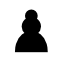
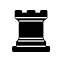
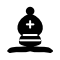
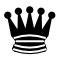
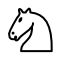
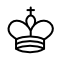
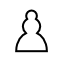
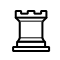
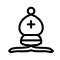
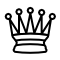
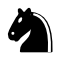
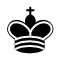

In [7]:
result = env.run(["main.py", "random"])
print("Agent exit status/reward/time left: ")
# look at the generated replay.json and print out the agent info
for agent in result[-1]:
    print("\t", agent.status, "/", agent.reward, "/", agent.observation.remainingOverageTime)
print("\n")
# render the game
env.render(mode="ipython", width=1000, height=1000) 